# Crop Yield Prediction for African Food Security

## Mission
Food security across Africa depends on knowing what farmland can realistically
produce. This project predicts crop yield in hectograms per hectare for African
countries, so that planners can estimate output from climate and input conditions
before a season ends.

## Dataset
The data comes from the Crop Yield Prediction Dataset on Kaggle, which merges
crop yield and pesticide figures from the FAO with rainfall and temperature data
from the World Bank. The full file covers 101 countries from 1990 to 2013. For
this project it was filtered to Africa only, leaving 5,362 rows across 31 African
countries and 10 staple crops including maize, cassava, sorghum, yams and rice.
Each row records one crop in one country in one year, along with that country's
rainfall, pesticide use and average temperature.

In [1]:
import pandas as pd

df = pd.read_csv("yield_df.csv")

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isna().sum())

Shape: (28242, 8)

Column types:
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

First rows:
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3      

## First look at the data

The raw file has 28,242 rows and 8 columns with no missing values anywhere, so
there are no gaps to fill. The first column, "Unnamed: 0", is just a leftover row
number saved into the CSV by accident. It carries no information about crops or
yield, so it is dropped.

The target variable is hg/ha_yield. Everything else is a possible predictor.

In [2]:
# Drop the leftover index column
df = df.drop(columns=["Unnamed: 0"])

# Confirm it's gone and see summary statistics
print(df.shape)
print(df.describe())

# See how many unique countries and crops we have
print("\nNumber of countries:", df["Area"].nunique())
print("Number of crops:", df["Item"].nunique())
print("\nCrops in the data:")
print(df["Item"].unique())

(28242, 7)
               Year    hg/ha_yield  average_rain_fall_mm_per_year  \
count  28242.000000   28242.000000                    28242.00000   
mean    2001.544296   77053.332094                     1149.05598   
std        7.051905   84956.612897                      709.81215   
min     1990.000000      50.000000                       51.00000   
25%     1995.000000   19919.250000                      593.00000   
50%     2001.000000   38295.000000                     1083.00000   
75%     2008.000000  104676.750000                     1668.00000   
max     2013.000000  501412.000000                     3240.00000   

       pesticides_tonnes      avg_temp  
count       28242.000000  28242.000000  
mean        37076.909344     20.542627  
std         59958.784665      6.312051  
min             0.040000      1.300000  
25%          1702.000000     16.702500  
50%         17529.440000     21.510000  
75%         48687.880000     26.000000  
max        367778.000000     30.650000 

## Filtering to Africa and cleaning

The dataset is filtered down to the 31 African countries it contains. Checking
the excluded countries confirmed that none were missed because of spelling
differences, so this is every African country available in the source data.

161 duplicate rows were found and removed. Duplicates would give repeated records
extra weight during training, which distorts what the model learns.

The remaining 5,362 rows were checked for impossible values. Yield ranges from
849 to 400,000 hg/ha, rainfall from 51 to 2,041 mm, temperature from 13.9 to
30.7 degrees, and pesticide use from 0.04 to 26,857 tonnes. All of these are
physically sensible for African agriculture, so no rows were removed as errors.

Extreme values were deliberately kept. Some countries genuinely produce very high
or very low yields, and that is real information rather than a mistake in the data.

In [3]:
# List of African countries as they appear in FAO-style data
african_countries = [
    "Algeria", "Angola", "Botswana", "Burkina Faso", "Burundi", "Cameroon",
    "Central African Republic", "Chad", "Egypt", "Eritrea", "Ethiopia",
    "Ghana", "Guinea", "Guinea-Bissau", "Kenya", "Lesotho", "Liberia",
    "Libya", "Madagascar", "Malawi", "Mali", "Mauritania", "Mauritius",
    "Morocco", "Mozambique", "Namibia", "Niger", "Nigeria", "Rwanda",
    "Senegal", "Sierra Leone", "South Africa", "Sudan", "Tunisia",
    "Uganda", "Tanzania", "Zambia", "Zimbabwe", "Ivory Coast",
    "Côte d'Ivoire", "Democratic Republic of the Congo", "Congo", "Gabon",
    "Togo", "Benin", "Comoros", "Djibouti", "Eswatini", "Gambia"
]

# See which of these actually exist in your data first
countries_in_data = df["Area"].unique()
present = [c for c in african_countries if c in countries_in_data]
print("African countries found in the data:")
print(present)
print("\nHow many:", len(present))

# Filter
df_africa = df[df["Area"].isin(present)].copy()
print("\nRows after filtering to Africa:", df_africa.shape[0])
print("Crops present:", df_africa["Item"].nunique())
print("Countries present:", df_africa["Area"].nunique())

African countries found in the data:
['Algeria', 'Angola', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Egypt', 'Eritrea', 'Ghana', 'Guinea', 'Kenya', 'Lesotho', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Rwanda', 'Senegal', 'South Africa', 'Sudan', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']

How many: 31

Rows after filtering to Africa: 5523
Crops present: 10
Countries present: 31


In [4]:
# 1. Check for duplicate rows
print("Duplicate rows:", df_africa.duplicated().sum())

# Remove them if any
df_africa = df_africa.drop_duplicates()
print("Rows after removing duplicates:", df_africa.shape[0])

# 2. Check for missing values (confirm still clean after filtering)
print("\nMissing values:")
print(df_africa.isna().sum())

# 3. Sanity-check for impossible values in each numeric column
print("\nValue ranges (look for anything impossible):")
print(df_africa[["Year", "hg/ha_yield", "average_rain_fall_mm_per_year",
                 "pesticides_tonnes", "avg_temp"]].describe())
# Point df at the cleaned African data so all cells below use it
df = df_africa.copy()
print("df now has:", df.shape[0], "rows and", df["Area"].nunique(), "countries")

Duplicate rows: 161
Rows after removing duplicates: 5362

Missing values:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Value ranges (look for anything impossible):
              Year    hg/ha_yield  average_rain_fall_mm_per_year  \
count  5362.000000    5362.000000                    5362.000000   
mean   2001.587840   54525.229579                     785.496643   
std       7.079519   65639.272364                     526.756508   
min    1990.000000     849.000000                      51.000000   
25%    1995.000000   11656.500000                     346.000000   
50%    2001.000000   25681.500000                     686.000000   
75%    2008.000000   68684.750000                    1187.000000   
max    2013.000000  400000.000000                    2041.000000   

       pe

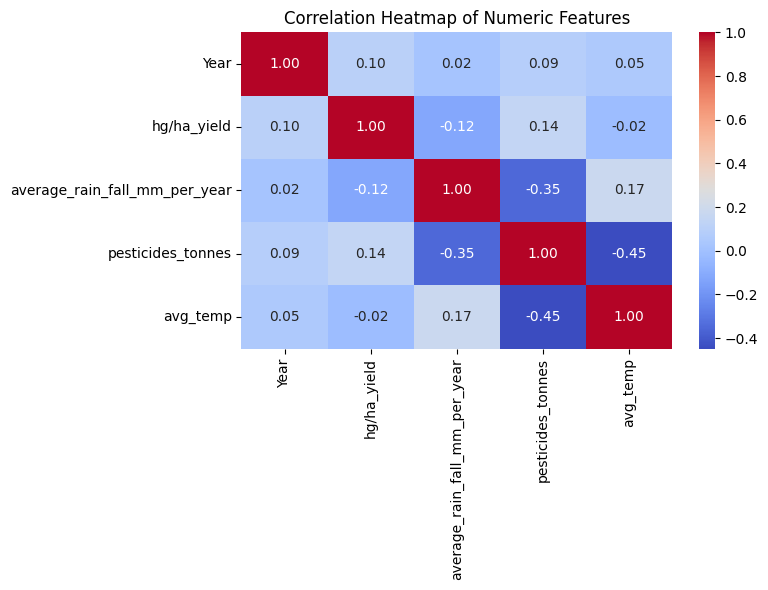

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap of the numeric columns
numeric_cols = ["Year", "hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## What the correlations show

None of the numeric features has a strong straight line relationship with yield.
The strongest is pesticide use at 0.14, followed by rainfall at -0.12, with
temperature almost flat at -0.02.

This is worth pausing on, because it shapes the whole modelling approach. Rainfall,
pesticide use and temperature are recorded once per country per year, so every crop
grown in the same country in the same year shares identical weather values. But
yield varies enormously between crops. Cassava and yams produce on a completely
different scale from sorghum or wheat.

That means the strongest signal in this dataset is not in the numbers on this
heatmap at all. It sits in the two categorical columns, crop type and country,
which cannot appear in a numeric correlation matrix. This is the first sign that a
straight line model will struggle and that a model able to split on categories will
do much better.

The heatmap also shows pesticide use and temperature moving in opposite directions
at -0.45, and rainfall and pesticide use at -0.35. Cooler, drier countries in this
sample tend to use more pesticides, which likely reflects differences in farming
systems rather than anything about the weather itself.

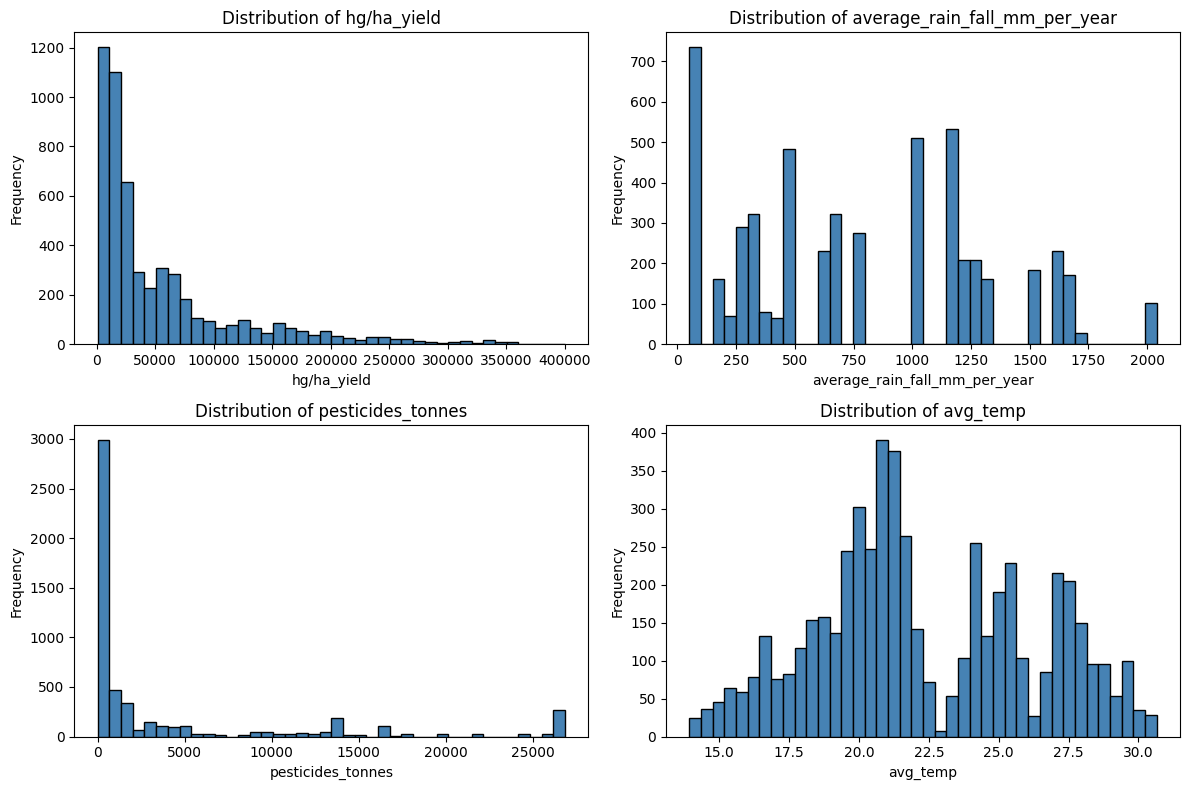

In [6]:
# Distribution of the target and numeric features
numeric_cols = ["hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## What the distributions show

Yield is heavily right skewed. Most records sit below 70,000 hg/ha while a long
tail stretches out towards 400,000. The mean of 54,525 sitting well below the
maximum confirms this. Pesticide use is skewed even more sharply, with most
countries using small amounts and a few using very large quantities.

Rainfall is lumpy rather than smooth, with several separate peaks. This happens
because rainfall is a country level figure, so the same value repeats across every
crop grown in that country that year. Each peak is a cluster of countries rather
than a natural spread.

Temperature is the most evenly spread of the four, concentrated between about 19
and 27 degrees, which fits a set of mostly tropical and subtropical countries.

Two things follow from this. The features sit on wildly different scales, from
temperatures in the tens to pesticide figures in the tens of thousands, so they
need to be standardised before training or the large numbers will dominate simply
for being large. And the skew in the target is another reason a linear model will
find this data hard to fit.

In [7]:
from sklearn.preprocessing import LabelEncoder

# Make a copy so we keep the original safe
df_encoded = df.copy()

# Encode the two categorical text columns into numbers
area_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df_encoded["Area"] = area_encoder.fit_transform(df_encoded["Area"])
df_encoded["Item"] = item_encoder.fit_transform(df_encoded["Item"])

# Check the result
print(df_encoded.head())
print("\nData types now:")
print(df_encoded.dtypes)

     Area  Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
99      0     1  1990        16500                           89.0   
100     0     3  1990        78936                           89.0   
101     0     4  1990        28000                           89.0   
102     0     5  1990        16571                           89.0   
103     0     8  1990         6315                           89.0   

     pesticides_tonnes  avg_temp  
99             1828.92     17.48  
100            1828.92     17.48  
101            1828.92     17.48  
102            1828.92     17.48  
103            1828.92     17.48  

Data types now:
Area                               int64
Item                               int64
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


## Preparing the data for modelling

Area and Item are text, and models can only work with numbers, so both are
converted using label encoding. Each country and each crop becomes an integer.
One hot encoding was considered but rejected here, because 31 countries plus 10
crops would create 41 extra columns from a dataset of only 6 predictors. Label
encoding keeps the feature set compact, and the tree based models used later
handle integer coded categories well since they split on values rather than
assuming any order between them.

The data is then split 80 to 20 into 4,289 training rows and 1,073 test rows. The
test rows are held back completely so that performance can be measured on records
the model has never seen.

Finally the features are standardised so each one has a mean of 0 and a similar
spread. Note that the scaler is fitted on the training data only and then applied
to the test data. Fitting it on everything would let information from the test set
leak into training, which would make the results look better than they really are.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = the 6 predictors, y = the target we want to predict
X = df_encoded.drop(columns=["hg/ha_yield"])
y = df_encoded["hg/ha_yield"]

# Split: 80% to train the models, 20% held back to test them fairly
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

# Standardize: put every feature on the same scale (mean 0, spread 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done. Example of scaled training row:")
print(X_train_scaled[0])

Training rows: 4289
Testing rows: 1073
Number of features: 6

Scaling done. Example of scaled training row:
[-0.95556235 -0.14773127  0.05099587 -1.38604253  0.16308298  0.0356778 ]


In [9]:
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Dictionary to hold our models
models = {
    "SGD (Gradient Descent)": SGDRegressor(max_iter=1000, random_state=42),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    # Train on the scaled training data
    model.fit(X_train_scaled, y_train)
    # Predict on the held-out test data
    preds = model.predict(X_test_scaled)
    # Measure error
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name:25s} | RMSE: {rmse:10.2f} | R2: {r2:.4f}")

SGD (Gradient Descent)    | RMSE:   64912.34 | R2: 0.0656
Linear Regression         | RMSE:   64842.14 | R2: 0.0676
Decision Tree             | RMSE:   14456.28 | R2: 0.9537
Random Forest             | RMSE:   15076.42 | R2: 0.9496


## Comparing the models

Four models were trained on the same data and measured on the same held out test
set, using RMSE as the loss metric. RMSE is the average size of the error in
hectograms per hectare, so lower is better.

Stochastic Gradient Descent reached an RMSE of 64,912 with an R squared of 0.066.
Ordinary Linear Regression was almost identical at 64,842 and 0.068. The Decision
Tree reached 14,456 with an R squared of 0.954, and the Random Forest 15,076 with
0.950.

The gap is stark. Both linear models explain under 7 percent of the variation in
yield, while both tree models explain over 95 percent.

The reason is the one the correlation heatmap pointed to. Yield is driven mostly by
which crop is being grown. A linear model has to describe every crop with a single
straight relationship, so it ends up predicting something close to the average for
everything. A tree can branch, asking first which crop this is and then which
country, which is exactly the shape of the underlying pattern.

The Decision Tree edges out the Random Forest here by a small margin. The two are
close enough to be near equivalent, but the rule is to keep the model with the
lowest loss, so the Decision Tree is selected and saved. It has the practical
advantage of being far smaller on disk, which makes deployment simpler.

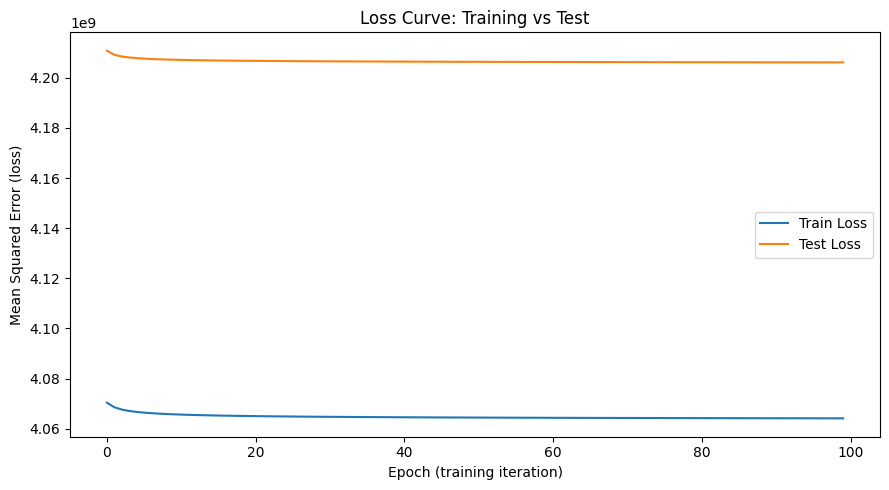

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# partial_fit lets us train one step at a time and record loss cleanly
sgd = SGDRegressor(learning_rate="invscaling", eta0=0.01, random_state=42)

n_epochs = 100
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(range(n_epochs), train_losses, label="Train Loss")
plt.plot(range(n_epochs), test_losses, label="Test Loss")
plt.xlabel("Epoch (training iteration)")
plt.ylabel("Mean Squared Error (loss)")
plt.title("Loss Curve: Training vs Test")
plt.legend()
plt.tight_layout()
plt.show()

## What the loss curve shows

Both the training and test loss fall over the first few epochs and then flatten
out, which is the shape you want to see. The two lines stay close together and
roughly parallel, meaning the model performs similarly on data it trained on and
data it has never seen, so there is no serious overfitting.

The important detail is where the curve settles. It converges at a very high loss
and barely improves after that. This is not a problem with the training process,
it is the linear model reaching the limit of what a straight line can do with this
data. It matches the low R squared reported earlier and reinforces the case for a
tree based model.

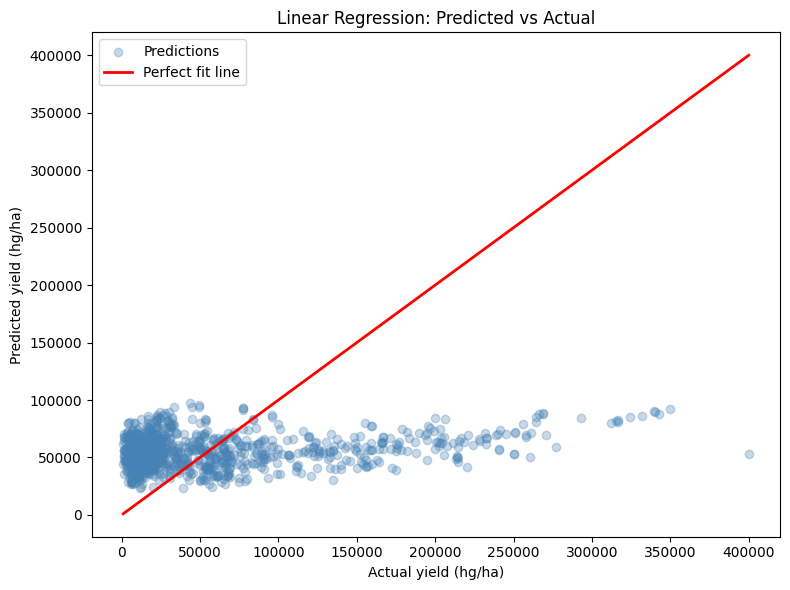

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Use the SGD linear model's predictions on the test set
y_pred_line = sgd.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_line, alpha=0.3, color="steelblue", label="Predictions")

# The diagonal: where perfect predictions would land
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linewidth=2, label="Perfect fit line")

plt.xlabel("Actual yield (hg/ha)")
plt.ylabel("Predicted yield (hg/ha)")
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

## What the scatter plot shows

Each point is one test record, with the true yield on the horizontal axis and the
model's prediction on the vertical axis. The red diagonal marks where points would
sit if predictions were perfect.

The points form a flat horizontal band instead of following the diagonal. Records
with a true yield of 300,000 receive roughly the same prediction as records near
zero. In other words the linear model is falling back on something close to the
average for every input, because no straight line combination of these six
features can separate a high yielding crop from a low yielding one.

This is the third piece of evidence pointing the same way, after the weak
correlations and the high plateaued loss. All three support selecting a tree based
model instead.

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib, os, numpy as np

# Decision Tree had the lowest RMSE on the African data, so it is our best model
best_model = DecisionTreeRegressor(random_state=42)
best_model.fit(X_train_scaled, y_train)

preds = best_model.predict(X_test_scaled)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 2))
print("R²:", round(r2_score(y_test, preds), 4))

bundle = {
    "model": best_model,
    "scaler": scaler,
    "area_encoder": area_encoder,
    "item_encoder": item_encoder,
    "feature_order": list(X.columns),
}

joblib.dump(bundle, "best_model.pkl", compress=3)
print("Size (MB):", round(os.path.getsize("best_model.pkl") / 1e6, 3))

RMSE: 14456.28
R²: 0.9537
Size (MB): 0.105


In [13]:
import joblib
import numpy as np

# Load the bundle back (proves the saved file works)
loaded = joblib.load("best_model.pkl")
model = loaded["model"]

# Take ONE row from the test set
single_row = X_test.iloc[[0]]           # raw, unscaled, one row
true_value = y_test.iloc[0]             # its real yield

# Scale it with the SAME scaler, then predict
single_row_scaled = loaded["scaler"].transform(single_row)
predicted = model.predict(single_row_scaled)[0]

print("Input row (raw features):")
print(single_row)
print(f"\nActual yield:    {true_value:.0f} hg/ha")
print(f"Predicted yield: {predicted:.0f} hg/ha")
print(f"Difference:      {abs(true_value - predicted):.0f} hg/ha")

Input row (raw features):
       Area  Item  Year  average_rain_fall_mm_per_year  pesticides_tonnes  \
27287    28     2  2006                         1180.0               88.0   

       avg_temp  
27287     23.95  

Actual yield:    53989 hg/ha
Predicted yield: 55012 hg/ha
Difference:      1023 hg/ha
